# Model Training & Evaluation

Train a gradient boosting model on the curated second-hand car data.
The business prefers slight **underestimation** of price — we achieve this with quantile regression (`alpha < 0.5`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../curated_data.csv")

# Alternative: load directly from S3
# import boto3, io
# s3 = boto3.client("s3")
# obj = s3.get_object(Bucket="snapsoft-hw-zcsikos-curated", Key="ml_sample_data_snapsoft.csv")
# df = pd.read_csv(io.BytesIO(obj["Body"].read()))

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 235 rows x 20 columns


,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,color,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg,Price
0,diesel,std,four,hatchback,fwd,front,95.7,yellow,166.3,64.4,52.8,2275,4.0,110,22.5,56.0,4500,38,47,7788.0
1,gas,std,four,wagon,4wd,front,95.7,purple,169.7,63.6,59.1,3110,4.0,92,9.0,62.0,4800,27,32,8778.0
2,gas,std,two,hatchback,rwd,front,98.4,navy,176.2,65.6,52.0,2714,4.0,146,9.3,116.0,4800,24,30,11549.0
3,gas,std,two,hatchback,rwd,front,102.9,fuchsia,183.5,67.7,52.0,3016,6.0,171,9.3,161.0,5200,19,24,15998.0
4,gas,std,four,sedan,fwd,front,100.4,yellow,184.6,66.5,55.1,3060,6.0,181,9.0,152.0,5200,19,25,13499.0


## 1. Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fueltype          235 non-null    str    
 1   aspiration        235 non-null    str    
 2   doornumber        235 non-null    str    
 3   carbody           235 non-null    str    
 4   drivewheel        235 non-null    str    
 5   enginelocation    226 non-null    str    
 6   wheelbase         235 non-null    float64
 7   color             235 non-null    str    
 8   carlength         231 non-null    float64
 9   carwidth          235 non-null    float64
 10  carheight         235 non-null    float64
 11  curbweight        235 non-null    int64  
 12  cylindernumber    227 non-null    float64
 13  enginesize        235 non-null    int64  
 14  compressionratio  235 non-null    float64
 15  horsepower        235 non-null    float64
 16  peakrpm           235 non-null    int64  
 17  citympg 

In [4]:
df.describe()

,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg,Price
count,235.000000,231.000000,235.000000,235.000000,235.000000,227.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000
mean,98.576596,173.641558,65.840851,53.639574,2543.331915,4.361233,126.059574,10.180979,103.157447,5115.744681,25.370213,30.957447,13041.870923
std,5.883296,12.063445,2.090769,2.430998,509.763445,1.044113,40.195844,4.056151,38.420034,470.732039,6.506667,6.842419,7757.915869
min,86.600000,141.100000,60.300000,47.800000,1488.000000,2.000000,61.000000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,94.500000,166.300000,64.050000,51.600000,2145.000000,4.000000,98.000000,8.500000,70.000000,4800.000000,19.500000,25.000000,7775.000000
50%,96.500000,173.000000,65.400000,54.100000,2405.000000,4.000000,119.000000,9.000000,95.000000,5100.000000,24.000000,30.000000,9995.000000
75%,101.200000,180.250000,66.500000,55.500000,2921.000000,4.000000,141.000000,9.400000,116.000000,5500.000000,30.000000,35.000000,16501.500000
max,120.900000,208.100000,72.300000,59.800000,4066.000000,12.000000,326.000000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [5]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

enginelocation    9
carlength         4
cylindernumber    8
dtype: int64

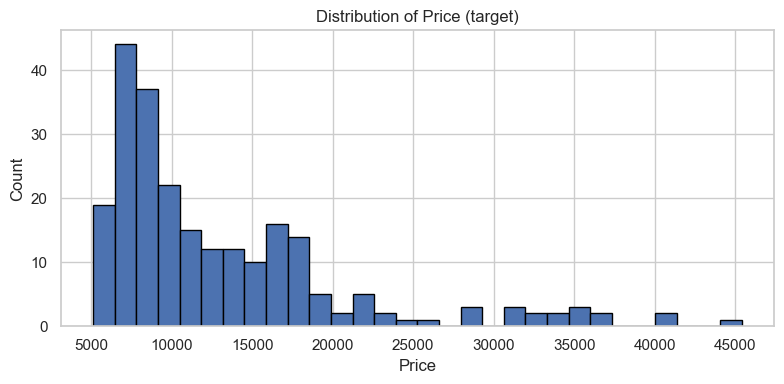

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["Price"], bins=30, edgecolor="black")
ax.set_xlabel("Price")
ax.set_ylabel("Count")
ax.set_title("Distribution of Price (target)")
plt.tight_layout()
plt.show()

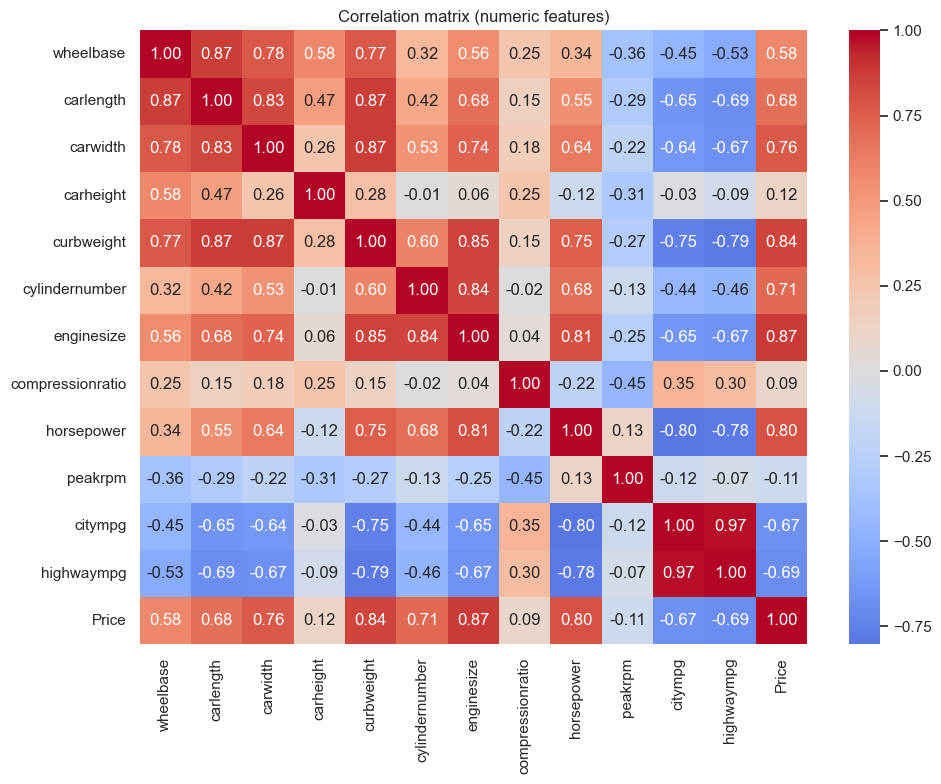

In [7]:
numeric_cols = df.select_dtypes(include="number").columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

In [8]:
price_corr = corr["Price"].drop("Price").sort_values(ascending=False)
print("Correlation with Price:")
print(price_corr.to_string())

Correlation with Price:
enginesize          0.873603
curbweight          0.839337
horsepower          0.798310
carwidth            0.764493
cylindernumber      0.711341
carlength           0.677798
wheelbase           0.579545
carheight           0.123276
compressionratio    0.087096
peakrpm            -0.105890
citympg            -0.673937
highwaympg         -0.686028


## 2. Feature Engineering & Preprocessing

In [9]:
TARGET = "Price"
X = df.drop(columns=[TARGET])
y = df[TARGET]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include="number").columns.tolist()

print(f"Categorical ({len(cat_cols)}): {cat_cols}")
print(f"Numeric     ({len(num_cols)}): {num_cols}")

Categorical (7): ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'color']
Numeric     (12): ['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'cylindernumber', 'enginesize', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']


C:\Users\ZCsikos\AppData\Local\Temp\ipykernel_14312\2549025054.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


In [10]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

## 3. Train / Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

Train: 188 rows | Test: 47 rows


## 4. Model Training

We use `GradientBoostingRegressor` with **quantile loss** (`alpha=0.4`).

Quantile regression at the 40th percentile means the model learns to predict a value
such that 40% of actual prices fall below it — or equivalently, ~60% of predictions
will underestimate the true price. This directly satisfies the business requirement
for slight underestimation without any post-hoc adjustment.

In [12]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(
        loss="quantile",
        alpha=0.4,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
    )),
])

model.fit(X_train, y_train)
print("Training complete.")

Training complete.


## 5. Evaluation

In [13]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
underestimation_rate = np.mean(y_pred < y_test)

print(f"MAE:                   {mae:,.0f}")
print(f"RMSE:                  {rmse:,.0f}")
print(f"R²:                    {r2:.3f}")
print(f"Underestimation rate:  {underestimation_rate:.1%}")

MAE:                   1,597
RMSE:                  2,398
R²:                    0.939
Underestimation rate:  55.3%


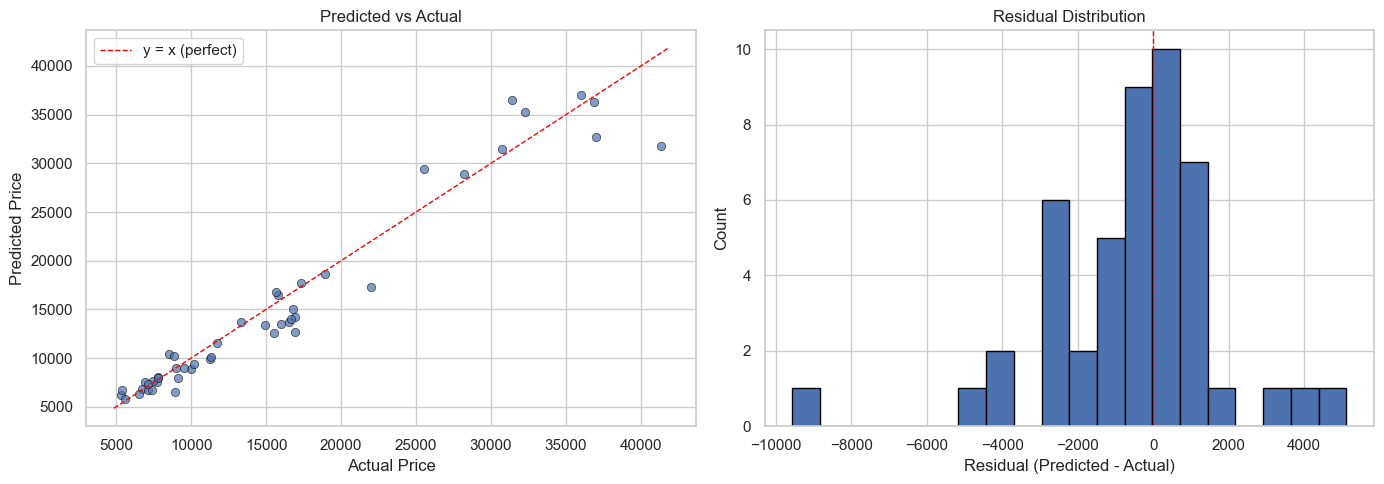

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.7, edgecolors="black", linewidths=0.5)
lims = [min(y_test.min(), y_pred.min()) - 500, max(y_test.max(), y_pred.max()) + 500]
ax.plot(lims, lims, "--", color="red", linewidth=1, label="y = x (perfect)")
ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.set_title("Predicted vs Actual")
ax.legend()

ax = axes[1]
residuals = y_pred - y_test
ax.hist(residuals, bins=20, edgecolor="black")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Residual (Predicted - Actual)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution")

plt.tight_layout()
plt.show()

## 6. Discussion

**Model choice — why `GradientBoostingRegressor`?**

Gradient boosting is the go-to algorithm for small-to-medium tabular datasets. It handles
mixed feature types well, doesn't require feature scaling, and achieves strong predictive
performance without extensive tuning. The classic `GradientBoostingRegressor` was chosen over
`HistGradientBoostingRegressor` because it natively supports `loss='quantile'`, which is the
mechanism we use for underestimation.

**Underestimation via quantile loss**

Setting `loss='quantile'` with `alpha=0.4` trains the model to predict the 40th percentile
of the conditional price distribution. The loss function penalizes over-predictions more
heavily than under-predictions (by a factor of `alpha / (1 - alpha) = 2/3`), so the model
naturally learns to err on the low side. The `alpha` parameter is a direct, interpretable
control knob — lowering it increases the underestimation bias, raising it toward 0.5 makes
the model symmetric.

**Limitations**

- **Small dataset** (235 rows): overfitting is the main risk. We mitigate with a held-out
  test set and conservative hyperparameters (max_depth=4, n_estimators=200).
- **No cross-validation**: with so few samples, k-fold CV would give high-variance estimates.
  A single 80/20 split is pragmatic here.
- **No hyperparameter tuning**: we use sensible defaults. In production you'd run a grid or
  Bayesian search over `n_estimators`, `max_depth`, `learning_rate`, and `alpha`.